# ***Loan Approval Prediction Using Machine Learning***

Loan approval is an important decision for financial institutions. It depends on various factors.Manual assessment of loan applications can be time-consuming and may not always provide consistent decisions.This project aims to use machine learning techniques to predict whether a loan application is likely to be approved or rejected based on the characteristics of the applicant.

## OBJECTIVE 

The main objective of this project is to reimplement and enhance my previous BSc project on loan approval prediction using a more comprehensive machine learning workflow in Python.

The improved project aims to:

- Perform comprehensive univariate, bivariate and multivariate exploratory data analysis.

- Apply appropriate data preprocessing techniques, including data cleaning, missing-value imputation, categorical encoding  and feature scaling.

- Identify and address class imbalance using SMOTE where appropriate.

- Develop multiple classification models, namely Logistic Regression, Decision Tree and Random Forest.

- Compare the models using multiple evaluation metrics such as accuracy, precision, recall, F1-score and ROC-AUC.

- Select the most suitable model based on its overall predictive performance.

- Build a system capable of generating loan approval predictions for new applicants.

- Deploy the final model using Gradio so that users can enter applicant information and obtain an interactive prediction.-

## Variables Description



The dataset contains information about loan applicants, their financial characteristics, credit history, assets and the final loan approval status.

| Variable | Description | Type |
|---|---|---|
| `loan_id` | A unique identification number assigned to each loan application. | Identifier |
| `no_of_dependents` | Number of people who are financially dependent on the applicant. | Numerical |
| `education` | Educational qualification of the applicant, either Graduate or Not Graduate. | Categorical |
| `self_employed` | Indicates whether the applicant is self-employed or not. | Categorical |
| `income_annum` | Annual income earned by the applicant. | Numerical |
| `loan_amount` | Amount of loan requested by the applicant. | Numerical |
| `loan_term` | Duration for which the loan is taken, measured in years. | Numerical |
| `cibil_score` | Credit score representing the applicant's credit history and creditworthiness. | Numerical |
| `residential_assets_value` | Estimated value of residential assets owned by the applicant. | Numerical |
| `commercial_assets_value` | Estimated value of commercial assets owned by the applicant. | Numerical |
| `luxury_assets_value` | Estimated value of luxury assets owned by the applicant. | Numerical |
| `bank_asset_value` | Estimated value of assets held by the applicant in banks or financial institutions. | Numerical |
| `loan_status` | Final outcome of the loan application, either Approved or Rejected. | Target / Categorical |

## Import Libraries

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
# Data Cleaning 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
# train test split 
from sklearn.model_selection import train_test_split
# Feature Scalling 
from sklearn.preprocessing import StandardScaler
# Smote
from imblearn.over_sampling import SMOTENC
# Modelling
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# model evaluation 
from sklearn.metrics import (accuracy_score , precision_score,recall_score,roc_auc_score,
                             confusion_matrix, roc_curve,classification_report,f1_score)
#saving
import joblib 

### Load Dataset

In [3]:
df=pd.read_csv("loan_approval_dataset.csv")

In [4]:
df.columns = df.columns.str.strip()

### Dataset Understanding

In [5]:
# gives no of rows and columns 
df.shape

(4269, 13)

In [6]:
# give random 15 rows from dataset
df.sample(15)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
3820,3821,4,Graduate,Yes,6000000,12900000,14,723,700000,1600000,13600000,4100000,Approved
659,660,0,Graduate,Yes,1200000,2700000,2,638,1500000,500000,2700000,1500000,Approved
774,775,0,Graduate,Yes,7300000,23300000,2,616,15700000,5900000,25800000,4100000,Approved
1921,1922,1,Graduate,Yes,7800000,16200000,2,335,4900000,7900000,28700000,6400000,Rejected
2360,2361,5,Not Graduate,No,2200000,8100000,4,409,300000,0,4900000,2400000,Rejected
2704,2705,5,Not Graduate,No,4900000,10800000,18,613,6800000,800000,14500000,5300000,Approved
1768,1769,4,Not Graduate,No,9900000,29100000,18,772,24100000,19400000,26800000,11700000,Approved
3660,3661,5,Not Graduate,No,3800000,10500000,10,759,1800000,6700000,8100000,5300000,Approved
1461,1462,3,Not Graduate,No,4100000,12200000,2,457,700000,500000,14100000,4900000,Rejected
1091,1092,4,Not Graduate,Yes,600000,2100000,6,558,1300000,1000000,2200000,300000,Approved


In [7]:
# give column names 
df.columns.tolist()

['loan_id',
 'no_of_dependents',
 'education',
 'self_employed',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value',
 'loan_status']

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   loan_id                   4269 non-null   int64
 1   no_of_dependents          4269 non-null   int64
 2   education                 4269 non-null   str  
 3   self_employed             4269 non-null   str  
 4   income_annum              4269 non-null   int64
 5   loan_amount               4269 non-null   int64
 6   loan_term                 4269 non-null   int64
 7   cibil_score               4269 non-null   int64
 8   residential_assets_value  4269 non-null   int64
 9   commercial_assets_value   4269 non-null   int64
 10  luxury_assets_value       4269 non-null   int64
 11  bank_asset_value          4269 non-null   int64
 12  loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 531.6 KB


In [12]:
print(df.dtypes)

loan_id                     int64
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object


In [13]:
# does there 0 value ?
(df==0).sum()

loan_id                       0
no_of_dependents            712
education                     0
self_employed                 0
income_annum                  0
loan_amount                   0
loan_term                     0
cibil_score                   0
residential_assets_value     45
commercial_assets_value     107
luxury_assets_value           0
bank_asset_value              8
loan_status                   0
dtype: int64

In [14]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [15]:
# labels in a categorical col
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())
    print()

education
<ArrowStringArray>
[' Graduate', ' Not Graduate']
Length: 2, dtype: str

self_employed
<ArrowStringArray>
[' No', ' Yes']
Length: 2, dtype: str

loan_status
<ArrowStringArray>
[' Approved', ' Rejected']
Length: 2, dtype: str



C:\Users\SWASTIKA\AppData\Local\Temp\ipykernel_21020\2342226509.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object'):


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
for col in df.select_dtypes(include="object"):
    print(df[col].value_counts())
    print()

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

self_employed
Yes    2150
No     2119
Name: count, dtype: int64

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64



C:\Users\SWASTIKA\AppData\Local\Temp\ipykernel_21020\3668712697.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):


In [18]:
df["no_of_dependents"].unique()

array([2, 0, 3, 5, 4, 1])

## ***Exploratory Data Analysis***

### Univariate EDA

(A) Categorical Variables

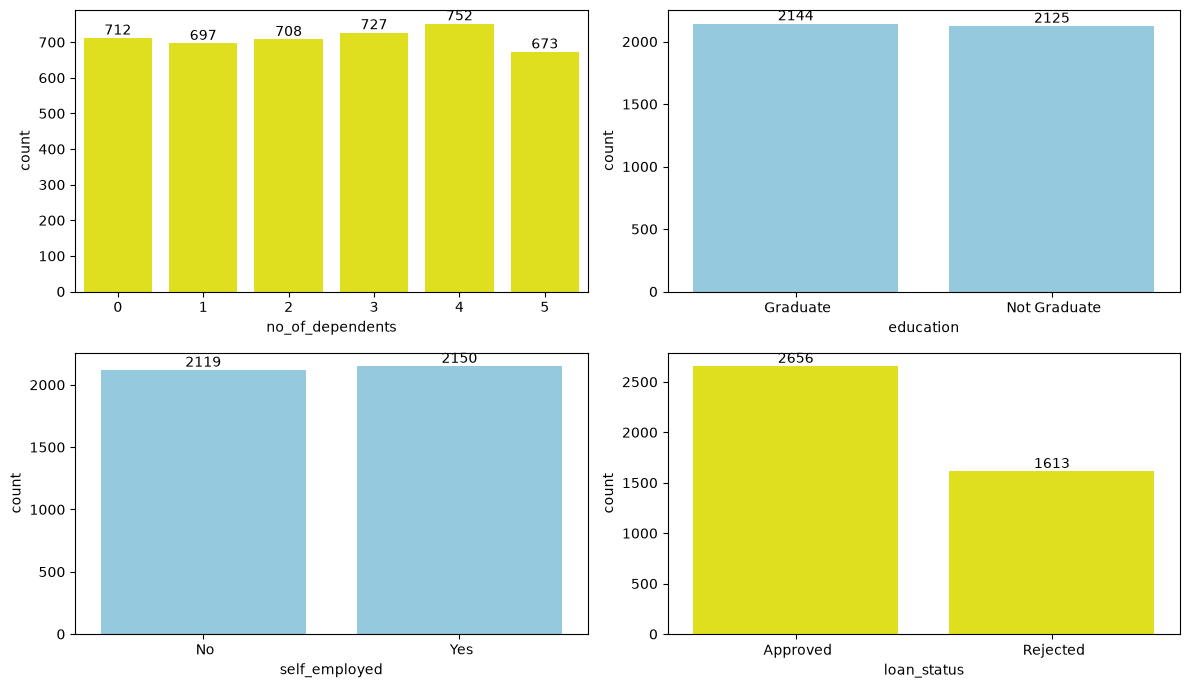

In [19]:
fig , ax =plt.subplots(2,2 , figsize=(12,7))
sns.countplot(data=df,x='no_of_dependents',ax=ax[0,0],color="yellow")
ax[0,0].bar_label(ax[0,0].containers[0])
sns.countplot(data=df,x="education",ax=ax[0,1],color="skyblue")
ax[0,1].bar_label(ax[0,1].containers[0])
sns.countplot(data=df,x="self_employed",ax=ax[1,0],color="skyblue")
ax[1,0].bar_label(ax[1,0].containers[0])
sns.countplot(data=df,x="loan_status",ax=ax[1,1],color="yellow")
ax[1,1].bar_label(ax[1,1].containers[0])
plt.tight_layout()
plt.show()

(B) Numerical Variables

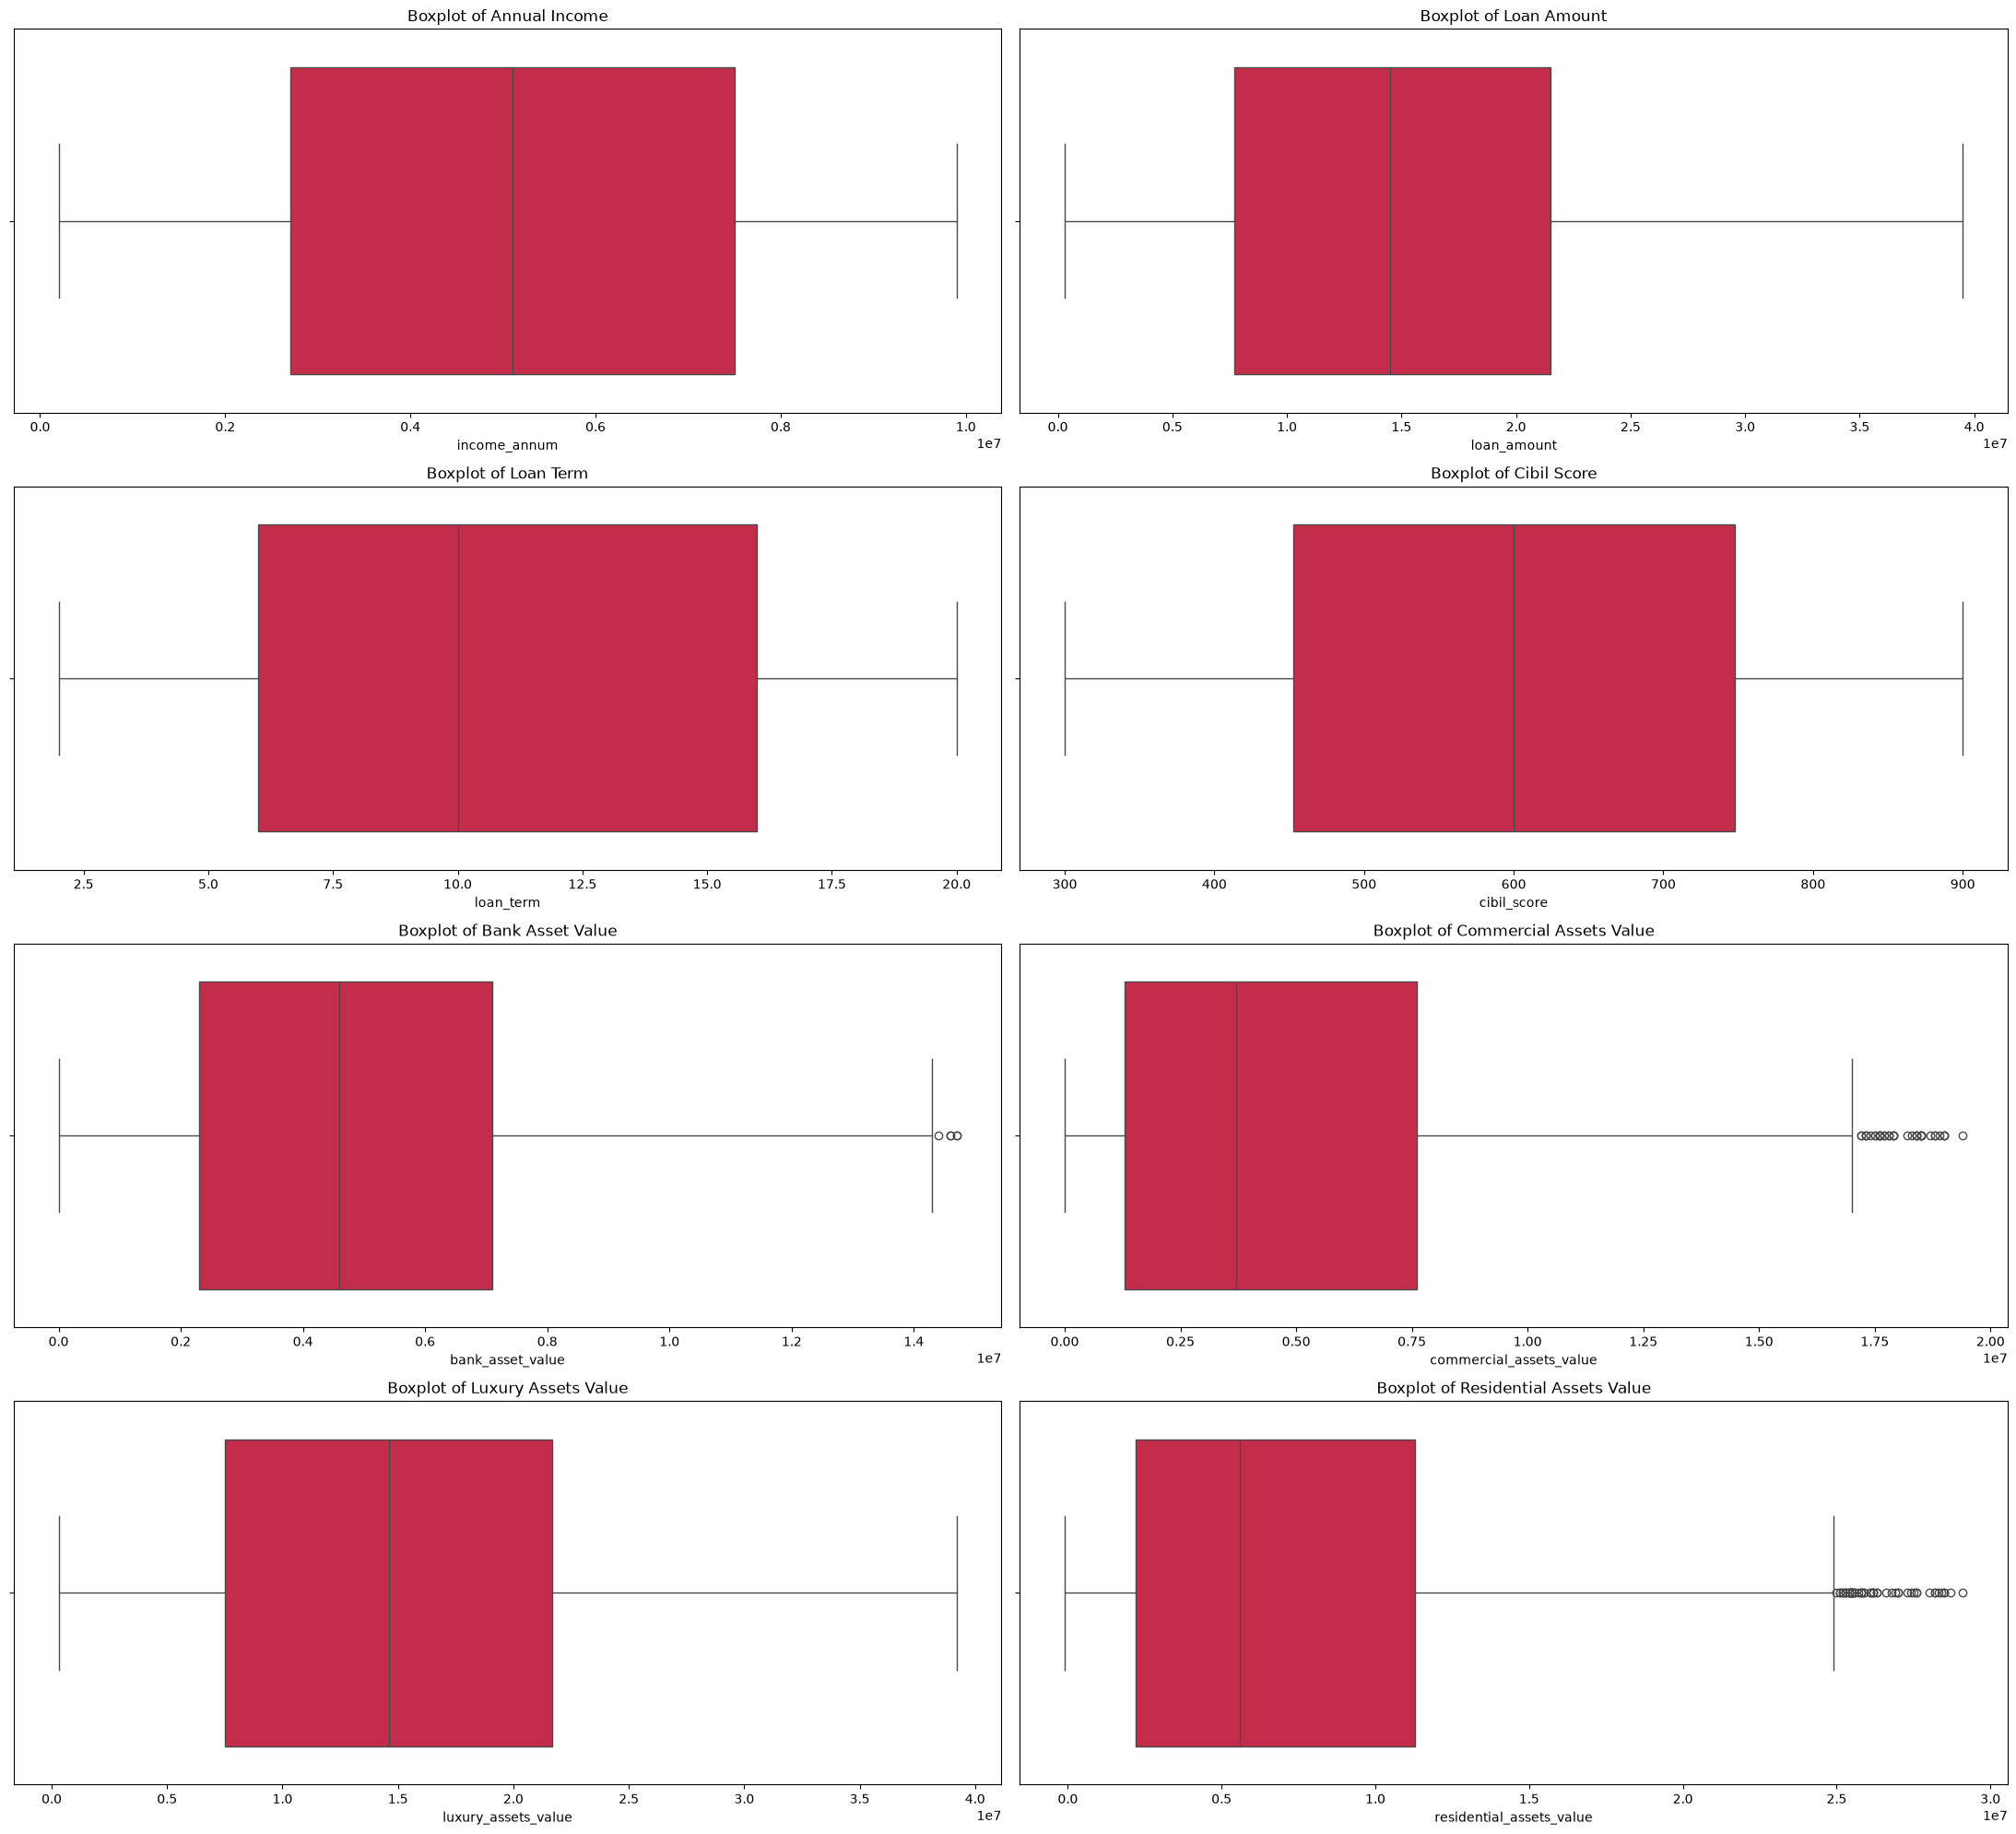

In [20]:
fig , ax= plt.subplots(4,2 , figsize=(22,20))
sns.boxplot(data=df,x=df["income_annum"],ax=ax[0,0],color="crimson")
ax[0,0].set_title("Boxplot of Annual Income")
sns.boxplot(data=df,x=df["loan_amount"],ax=ax[0,1],color="crimson")
ax[0,1].set_title("Boxplot of Loan Amount")
sns.boxplot(data=df,x=df["loan_term"],ax=ax[1,0],color="crimson")
ax[1,0].set_title("Boxplot of Loan Term")
sns.boxplot(data=df,x=df["cibil_score"],ax=ax[1,1],color="crimson")
ax[1,1].set_title("Boxplot of Cibil Score")
sns.boxplot(data=df,x=df["bank_asset_value"],ax=ax[2,0],color="crimson")
ax[2,0].set_title("Boxplot of Bank Asset Value")
sns.boxplot(data=df,x=df["commercial_assets_value"],ax=ax[2,1],color="crimson")
ax[2,1].set_title("Boxplot of Commercial Assets Value")
sns.boxplot(data=df,x=df["luxury_assets_value"],ax=ax[3,0],color="crimson")
ax[3,0].set_title("Boxplot of Luxury Assets Value")
sns.boxplot(data=df,x=df["residential_assets_value"],ax=ax[3,1],color="crimson")
ax[3,1].set_title("Boxplot of Residential Assets Value")
plt.tight_layout()
plt.show()

### Bivariate EDA

(A) Categorical vs Loan Status

- Correlation Heatmap

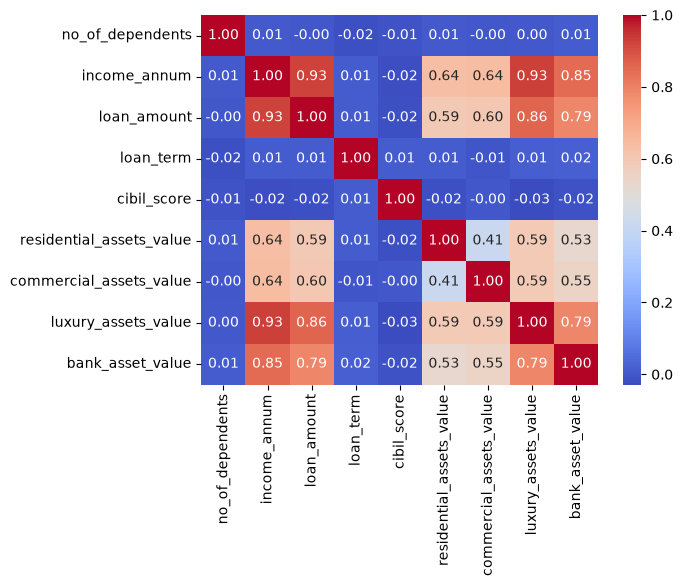

In [21]:
df_clean=df.drop(columns=['loan_id'],errors='ignore')
matrix=df_clean.select_dtypes(include="number").corr()
sns.heatmap(
    matrix,
    cmap="coolwarm",fmt=".2f",
    annot=True)
plt.show()

## Feature Engineering

In [9]:
# separate input output col
x=df.drop(columns=["loan_id","loan_status"] , errors="ignore")
y=df["loan_status"]

### Encode output

In [10]:
le=LabelEncoder()
y_new=le.fit_transform(y)

### Train test splitting

In [11]:
x_train,x_test,y_train,y_test=train_test_split(x,y_new,test_size=0.2,random_state=42)
#x_train.shape
y_train
#x_test.shape
#y_test.shape

array([0, 0, 0, ..., 1, 1, 0], shape=(3415,))

### Encoding

In [14]:
Transformer=ColumnTransformer(
    transformers=[
        ('tnf1',OrdinalEncoder(categories=[[' Not Graduate',' Graduate']],dtype=int),['education']),
        ('tnf2',OneHotEncoder(drop='first',
                sparse_output=False,dtype=int),['self_employed'])
    ],
    remainder="passthrough"
)
Transformer.set_output(transform="pandas")
x_train_new=Transformer.fit_transform(x_train)
x_test_new=Transformer.transform(x_test)

### Feature Scalling

In [15]:
sts=StandardScaler()
x_train_scale=sts.fit_transform(x_train_new)
x_test_scale=sts.transform(x_test_new)

### Modelling

In [16]:
pd.Series(y_train).value_counts()

0    2120
1    1295
Name: count, dtype: int64

Logistic Regression

In [17]:
model_log=LogisticRegression()
model_log.fit(x_train_scale,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [19]:
y_pred=model_log.predict(x_test_scale)
pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0
...,...,...
849,0,0
850,0,0
851,0,0
852,1,1


Evaluation 

In [20]:
# accuracy scsore
acc_sc=accuracy_score(y_test,y_pred)
print(f"Accuracy Score : ",acc_sc)
cm=confusion_matrix(y_test,y_pred)
print(f"Confusion Matrix  : \n",cm)
print(classification_report(y_test, y_pred))


Accuracy Score :  0.905152224824356
Confusion Matrix  : 
 [[498  38]
 [ 43 275]]
              precision    recall  f1-score   support

           0       0.92      0.93      0.92       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



***Logistic Regression***

Accuracy  = 90.5%

F1 (Rejected) = 0.92

F1 (Approved) = 0.87

**Logistic Using SMOTE**

use SMOTENC as SMOTE treats all cols as numerical but SMOTENC treats num as num and cat as cat

In [21]:
train_x,test_x,train_y,test_y=train_test_split(x,y_new,test_size=0.2,random_state=42)

In [24]:
categorical_var=[1,2]

In [25]:
smote_nc=SMOTENC(categorical_features=categorical_var,random_state=42)
x_train_smote,y_train_smote=smote_nc.fit_resample(train_x,train_y)

In [26]:
pd.Series(y_train_smote).value_counts()

0    2120
1    2120
Name: count, dtype: int64

In [27]:
x_train_smote_new=Transformer.fit_transform(x_train_smote)
x_test_new=Transformer.transform(test_x)

In [28]:
sts=StandardScaler()
x_train_smote_scale=sts.fit_transform(x_train_smote_new)
x_test_scale=sts.transform(x_test_new)

In [29]:
model_log_new=LogisticRegression()
model_log_new.fit(x_train_smote_scale,y_train_smote)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [30]:
y_smote_pred=model_log_new.predict(x_test_scale)

In [31]:
acc1=accuracy_score(test_y,y_smote_pred)
print(f"accuracy score = ",acc1)
cm=confusion_matrix(test_y,y_smote_pred)
print(f"Conofussion Matrix :\n ",cm)
print(classification_report(test_y,y_smote_pred))

accuracy score =  0.9110070257611241
Conofussion Matrix :
  [[487  49]
 [ 27 291]]
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       536
           1       0.86      0.92      0.88       318

    accuracy                           0.91       854
   macro avg       0.90      0.91      0.91       854
weighted avg       0.91      0.91      0.91       854



***Logistic Regression after SMOTENC***

Accuracy  = 91.1%

F1 (Rejected) = 0.93

F1 (Approved) = 0.88

***SMOTENC produced a modest improvement in overall accuracy and improved minority-class recall from 86% to 92%.***

## Tree Based Models 

### A. Decision Tree

In [32]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(x_train_new,y_train)
y_pred_dt=dt.predict(x_test_new)
pd.DataFrame({
     'Actual': y_test,
     'Predicted': y_pred_dt
 })

,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,0,0
4,0,0
...,...,...
849,0,0
850,0,0
851,0,0
852,1,1


In [34]:
print(f'Accuracy Score : ',accuracy_score(y_test,y_pred_dt))
print(f'Confusion matrix : \n',confusion_matrix(y_test,y_pred_dt))
print(classification_report(y_test,y_pred_dt))

Accuracy Score :  0.977751756440281
Confusion matrix : 
 [[527   9]
 [ 10 308]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [35]:
y_train_pred_dt = dt.predict(x_train_new)
print(y_train_pred_dt)

print(accuracy_score(y_train, y_train_pred_dt))

[0 0 0 ... 1 1 0]
1.0


Decision tree shows overfitting

In [36]:
model_dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

In [37]:
model_dt.fit(x_train_new, y_train)

y_pred_dt = model_dt.predict(x_test_new)

print(accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

0.968384074941452
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       536
           1       0.94      0.98      0.96       318

    accuracy                           0.97       854
   macro avg       0.96      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854



In [38]:
y_train_pred_dt5 = model_dt.predict(x_train_new)

accuracy_score(y_train, y_train_pred_dt5)

0.9756954612005857

1.For max_depth=5:

-Training accuracy = 97.57%

-Test accuracy = 96.84%

### B. Random Forest

In [74]:
rf=RandomForestClassifier(random_state=42)
rf.fit(x_train_new,train_y)
y_pred_rf=rf.predict(x_test_new)
print(f'Accuracy Score :',accuracy_score(test_y,y_pred_rf))
print(f'Confusion Matrix :\n',confusion_matrix(test_y,y_pred_rf))
print(classification_report(test_y,y_pred_rf))
print(f'Training accuracy : ',accuracy_score(train_y,rf.predict(x_train_new)))

Accuracy Score : 0.9800936768149883
Confusion Matrix :
 [[531   5]
 [ 12 306]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Training accuracy :  1.0


Training accuracy = 100%

Test accuracy     = 98.01%

Gap               = 1.99%

Hence overfitting in Random Forest model


In [40]:
model_rf = RandomForestClassifier(
    n_estimators=100, # build 100 trees
    max_depth=3,  #restrict each tree to 5 
    random_state=42
)

In [73]:
model_rf.fit(x_train_new, y_train)

y_pred_rf_us= model_rf.predict(x_test_new)

print("Test Accuracy:", accuracy_score(y_test, y_pred_rf_us))

y_train_pred_rf = model_rf.predict(x_train_new)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))

Test Accuracy: 0.9637002341920374
Train Accuracy: 0.9733528550512445


here we check the gap between for testing accuracy and test accuracy and check for max_depth = 3,5,7,10

### C. XGBoost 

In [42]:
xgb=XGBClassifier(random_state=42)
xgb.fit(x_train_new,train_y)
y_pred_xgb=xgb.predict(x_test_new)
print(f'Accuracy Score :',accuracy_score(test_y,y_pred_xgb))
print(f'Confusion Matrix :\n',confusion_matrix(test_y,y_pred_xgb))
print(classification_report(test_y,y_pred_xgb))
print(f'Training accuracy : ',accuracy_score(train_y,rf.predict(x_train_new)))

Accuracy Score : 0.9812646370023419
Confusion Matrix :
 [[529   7]
 [  9 309]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       536
           1       0.98      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854

Training accuracy :  1.0


In [43]:
xgb2 = XGBClassifier(
    max_depth=3,
    random_state=42
)

xgb2.fit(x_train_new, train_y)

y_pred_xgb2 = xgb2.predict(x_test_new)

print('Accuracy Score:', accuracy_score(test_y, y_pred_xgb2))

print('Confusion Matrix:\n', confusion_matrix(test_y, y_pred_xgb2))

print(classification_report(test_y, y_pred_xgb2))

print('Training accuracy:',
      accuracy_score(train_y, xgb2.predict(x_train_new)))

Accuracy Score: 0.9754098360655737
Confusion Matrix:
 [[525  11]
 [ 10 308]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       536
           1       0.97      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854

Training accuracy: 0.9997071742313324


### Cross Validation

In [44]:
from sklearn.model_selection import cross_val_score 

In [45]:
rf_cv=RandomForestClassifier(
    random_state=42
)
cross_val_rf=cross_val_score(
    rf_cv,
    x_train_new,train_y,cv=5,scoring='accuracy'
)

In [77]:
print(f"Cross validation scores of unrestricted Random Forest : ",cross_val_rf)
print(f"Cross mean validation scores of unrestricted Random Forest : ",cross_val_rf.mean())
diff_rf_cv=accuracy_score(test_y,y_pred_rf)-cross_val_rf.mean()
print(diff_rf_cv)

Cross validation scores of unrestricted Random Forest :  [0.98096633 0.97071742 0.97803807 0.98389458 0.97657394]
Cross mean validation scores of unrestricted Random Forest :  0.9780380673499268
0.0020556094650614476


In [54]:
xgb_cv=XGBClassifier(
    random_state=42
)
cross_val_xgb=cross_val_score(
    xgb_cv,
    x_train_new,train_y,cv=5,scoring='accuracy'
)

In [79]:
print(f"Cross validation scores of unrestricted XGBoost : ",cross_val_xgb)
print(f"Cross mean validation scores of unrestricted XGBoost : ",cross_val_xgb.mean())
diff_xgb_cv=accuracy_score(test_y,y_pred_xgb)-cross_val_xgb.mean()
print(diff_xgb_cv)


Cross validation scores of unrestricted XGBoost :  [0.97803807 0.97218155 0.9897511  0.98096633 0.97803807]
Cross mean validation scores of unrestricted XGBoost :  0.9797950219619327
0.0014696150404092112


In [65]:
xgb_cv_res=XGBClassifier(
    random_state=42 , max_depth=3
)
cross_val_xgb_res=cross_val_score(
    xgb_cv_res,
    x_train_new,train_y,cv=5,scoring='accuracy'
)

In [80]:
print(f"Cross validation scores of restricted XGBoost : ",cross_val_xgb_res)
print(f"Cross mean validation scores of restricted XGBoost : ",cross_val_xgb_res.mean())
diff_xgb_res_cv=accuracy_score(test_y,y_pred_xgb2)-cross_val_xgb.mean()
print(diff_xgb_res_cv)

Cross validation scores of restricted XGBoost :  [0.97071742 0.97071742 0.98828697 0.9795022  0.97510981]
Cross mean validation scores of restricted XGBoost :  0.9768667642752561
-0.004385185896358945


### Final Evaluation Table based on CV

|Model|Test Acuracy|Mean of CV score | Difference between Test Accuracy and Mean of CV|
|---|---|---|---|
|`Unrestricted Random Forest`| 0.9800936768149883 | 0.9780380673499268 | 0.0020556094650614476 |
|`Unrestricted XGBoost`| 0.9812646370023419 | 0.9797950219619327 | 0.0014696150404092112 |
|`Restricted XGBoost`| 0.9754098360655737 | 0.9768667642752561 | -0.004385185896358945 |

## **Final Model**

In [82]:
final_model = XGBClassifier(
    random_state=42
)

final_model.fit(x_train_new, train_y)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [83]:
final_pred = final_model.predict(x_test_new)

print("Final Model Accuracy:",
      accuracy_score(test_y, final_pred))

print("Final Model Classification Report:\n",
      classification_report(test_y, final_pred))

Final Model Accuracy: 0.9812646370023419
Final Model Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       536
           1       0.98      0.97      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [87]:
# Joblib
joblib.dump(Transformer,'loan_transformer.pkl')
joblib.dump(le,'Lable_Encoder.pkl')
joblib.dump(final_model,'Final_Model.pkl')

['Final_Model.pkl']

In [88]:
import joblib

loaded_transformer = joblib.load('loan_transformer.pkl')
loaded_model = joblib.load('Final_Model.pkl')
loaded_le = joblib.load('Lable_Encoder.pkl')


In [89]:
print(loaded_le.classes_)

[' Approved' ' Rejected']


### Deployment Test

In [90]:
user_data = pd.DataFrame({
    'no_of_dependents': [2],
    'education': [' Graduate'],
    'self_employed': [' No'],
    'income_annum': [5000000],
    'loan_amount': [15000000],
    'loan_term': [15],
    'cibil_score': [750],
    'residential_assets_value': [5000000],
    'commercial_assets_value': [2000000],
    'luxury_assets_value': [3000000],
    'bank_asset_value': [4000000]
})

In [91]:
user_data_transformed = loaded_transformer.transform(user_data)

In [92]:
prediction = loaded_model.predict(user_data_transformed)

print(prediction)

[0]


In [93]:
result = loaded_le.inverse_transform(prediction)

print(result[0])

 Approved
